In [67]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

In [32]:
ERA5_path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'
OISST_path= '/glade/work/acruz/Caribbean_Heat_data/OISST/'
HI_dmax = xr.open_dataset(ERA5_path+'dailymax_HI.nc')
ATL3 = xr.open_dataset(OISST_path+'ATL3.nc')
ONI = xr.open_dataset(OISST_path+'ONI.nc')
CANI_EANI = xr.open_dataset(OISST_path+'CANI_EANI_OISST.nc')
HI_dmax_month_anom = xr.open_dataset(ERA5_path+'HI_dmax_month_anom.nc')

In [33]:
RH = xr.open_dataset(ERA5_path+'RHanom_during_HIdmax.nc')
T  = xr.open_dataset(ERA5_path+'Tanom_during_HIdmax.nc')
U  = xr.open_dataset(ERA5_path+'U_Hidmax_anom.nc')
V  = xr.open_dataset(ERA5_path+'V_Hidmax_anom.nc')

In [34]:
idate = '1981-09-30'
fdate = '2026-02-28'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
ATL3 = ATL3['ATL3_OISST'].sel(time=slice(idate, fdate))
ONI = ONI['ONI_OISST'].sel(time=slice(idate, fdate))
HI_dmax_month_anom = HI_dmax_month_anom['HI_dmax_anom'].sel(time=slice(idate, fdate))
RH = RH['RHanom_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['Tanom_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U10_HIdmax_anom'].sel(time=slice(idate, fdate))
V = V['V10_HIdmax_anom'].sel(time=slice(idate, fdate))
CANI = CANI_EANI['CANI'].sel(time=slice(idate, fdate))
EANI = CANI_EANI['EANI'].sel(time=slice(idate, fdate))

In [73]:
CANI

<xarray.DataArray 'CANI' (time: 534)> Size: 4kB
[534 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-30 1981-10-31 ... 2026-02-28
Attributes:
    description:  Central Atlantic Niño Index. PCs scaled by STD. Rolling mea...

In [35]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 1GB
Dimensions:          (latitude: 82, longitude: 121, time: 16164)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 129kB 1981-09-30 ... 2025-12-31
    month            (time) int64 129kB 9 10 10 10 10 10 ... 12 12 12 12 12 12
Data variables:
    U10_HIdmax_anom  (time, latitude, longitude) float32 642MB ...
    V10_HIdmax_anom  (time, latitude, longitude) float32 642MB ...

# monthly means

In [36]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)

# LRS selection

In [37]:
# LRS = [8, 9, 10, 11]
# LRS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_ATL3 = ATL3.where(ATL3.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_ONI = ONI.where(ONI.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_CANI = CANI.where(CANI.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()
# LRS_EANI = EANI.where(EANI.time.dt.month.isin(LRS), drop=True).resample(time='YE').mean()

In [71]:
LRS = [8, 9, 10, 11]
LRS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(LRS), drop=True)
LRS_ATL3 = ATL3.where(ATL3.time.dt.month.isin(LRS), drop=True)
LRS_ONI = ONI.where(ONI.time.dt.month.isin(LRS), drop=True)
LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True)
LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True)
LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True)
LRS_CANI = CANI.where(CANI.time.dt.month.isin(LRS), drop=True)
LRS_EANI = EANI.where(EANI.time.dt.month.isin(LRS), drop=True)

# phase selection

In [38]:
def niño(ds):
    return ds >= 0.5


def niña(ds):
    return ds <= -0.5


def neutral(ds):
    return ((ds > -0.5) & (ds < 0.5) )

In [63]:
# o in the end is for niño, a is for niña, n for neutral
CANo = LRS_CANI_y.time.dt.year.where(niño(LRS_CANI_y), drop=True).rename('Warm CAN')
CANa = LRS_CANI_y.time.dt.year.where(niña(LRS_CANI_y), drop=True).rename('Cold CAN')
CANn = LRS_CANI_y.time.dt.year.where(neutral(LRS_CANI_y), drop=True).rename('Neutral CAN')

EANo = LRS_EANI_y.time.dt.year.where(niño(LRS_EANI_y), drop=True).rename('Warm EAN')
EANa = LRS_EANI_y.time.dt.year.where(niña(LRS_EANI_y), drop=True).rename('Cold EAN')
EANn = LRS_EANI_y.time.dt.year.where(neutral(LRS_EANI_y), drop=True).rename('Neutral EAN')

ATL3a= LRS_ATL3_y.time.dt.year.where(niña(LRS_ATL3_y), drop=True).rename('Cold ATL3')
ATL3o= LRS_ATL3_y.time.dt.year.where(niño(LRS_ATL3_y), drop=True).rename('Warm ATL3')
ATL3n= LRS_ATL3_y.time.dt.year.where(neutral(LRS_ATL3_y), drop=True).rename('Neutral ATL3')

ONIo = LRS_ONI_y.time.dt.year.where(niño(LRS_ONI_y), drop=True).rename('Warm ONI')
ONIa = LRS_ONI_y.time.dt.year.where(niña(LRS_ONI_y), drop=True).rename('Cold ONI')
ONIn = LRS_ONI_y.time.dt.year.where(neutral(LRS_ONI_y), drop=True).rename('Neutral ONI')

# idx season mean every year

In [40]:
LRS_CANI_y = LRS_CANI.resample(time='YE').mean()
LRS_EANI_y = LRS_EANI.resample(time='YE').mean()
LRS_ATL3_y = LRS_ATL3.resample(time='YE').mean()
LRS_ONI_y = LRS_ONI.resample(time='YE').mean()

### list of years

In [41]:
# o in the end is for niño, a is for niña, n for neutral
CANo = LRS_CANI_y.time.dt.year.where(niño(LRS_CANI_y), drop=True).rename('CANo')
CANa = LRS_CANI_y.time.dt.year.where(niña(LRS_CANI_y), drop=True).rename('CANa')
CANn = LRS_CANI_y.time.dt.year.where(neutral(LRS_CANI_y), drop=True).rename('CANn')

EANo = LRS_EANI_y.time.dt.year.where(niño(LRS_EANI_y), drop=True).rename('EANo')
EANa = LRS_EANI_y.time.dt.year.where(niña(LRS_EANI_y), drop=True).rename('EANa')
EANn = LRS_EANI_y.time.dt.year.where(neutral(LRS_EANI_y), drop=True).rename('EANn')

ATL3a= LRS_ATL3_y.time.dt.year.where(niña(LRS_ATL3_y), drop=True).rename('ATL3o')
ATL3o= LRS_ATL3_y.time.dt.year.where(niño(LRS_ATL3_y), drop=True).rename('ATL3a')
ATL3n= LRS_ATL3_y.time.dt.year.where(neutral(LRS_ATL3_y), drop=True).rename('ATL3n')

ONIo = LRS_ONI_y.time.dt.year.where(niño(LRS_ONI_y), drop=True).rename('ONIo')
ONIa = LRS_ONI_y.time.dt.year.where(niña(LRS_ONI_y), drop=True).rename('ONIa')
ONIn = LRS_ONI_y.time.dt.year.where(neutral(LRS_ONI_y), drop=True).rename('ONIn')

### lists

#### Atlantic Niño years

In [42]:
CANo

<xarray.DataArray 'CANo' (time: 9)> Size: 72B
array([2008., 2010., 2016., 2017., 2018., 2020., 2021., 2022., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 72B 2008-12-31 2010-12-31 ... 2023-12-31

In [43]:
EANo

<xarray.DataArray 'EANo' (time: 15)> Size: 120B
array([1998., 2003., 2004., 2008., 2010., 2012., 2016., 2017., 2018.,
       2019., 2020., 2021., 2022., 2023., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 120B 1998-12-31 2003-12-31 ... 2024-12-31

In [44]:
ATL3o

<xarray.DataArray 'ATL3a' (time: 9)> Size: 72B
array([1984., 1987., 2007., 2008., 2016., 2018., 2019., 2021., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 72B 1984-12-31 1987-12-31 ... 2023-12-31
Attributes:
    long_name:  Center time of the day

#### Atlantic Niña years

In [45]:
CANa

<xarray.DataArray 'CANa' (time: 15)> Size: 120B
array([1982., 1983., 1985., 1986., 1990., 1991., 1992., 1994., 1995.,
       1997., 2000., 2001., 2002., 2012., 2014.])
Coordinates:
  * time     (time) datetime64[ns] 120B 1982-12-31 1983-12-31 ... 2014-12-31

In [46]:
EANa

<xarray.DataArray 'EANa' (time: 10)> Size: 80B
array([1982., 1983., 1985., 1986., 1991., 1992., 1994., 1996., 2001.,
       2002.])
Coordinates:
  * time     (time) datetime64[ns] 80B 1982-12-31 1983-12-31 ... 2002-12-31

In [47]:
ATL3a

<xarray.DataArray 'ATL3o' (time: 2)> Size: 16B
array([1982., 1992.])
Coordinates:
  * time     (time) datetime64[ns] 16B 1982-12-31 1992-12-31
Attributes:
    long_name:  Center time of the day

#### ENSO years

In [48]:
ONIo

<xarray.DataArray 'ONIo' (time: 12)> Size: 96B
array([1982., 1987., 1991., 1997., 2002., 2004., 2006., 2009., 2012.,
       2015., 2018., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 96B 1982-12-31 1987-12-31 ... 2023-12-31
Attributes:
    long_name:  Center time of the day

In [49]:
ONIa

<xarray.DataArray 'ONIa' (time: 11)> Size: 88B
array([1984., 1985., 1988., 1995., 1998., 1999., 2000., 2007., 2010.,
       2020., 2022.])
Coordinates:
  * time     (time) datetime64[ns] 88B 1984-12-31 1985-12-31 ... 2022-12-31
Attributes:
    long_name:  Center time of the day

#### Neutral

In [50]:
CANn

<xarray.DataArray 'CANn' (time: 21)> Size: 168B
array([1981., 1984., 1987., 1988., 1989., 1993., 1996., 1998., 1999.,
       2003., 2004., 2005., 2006., 2007., 2009., 2011., 2013., 2015.,
       2019., 2024., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 168B 1981-12-31 1984-12-31 ... 2025-12-31

In [51]:
EANn

<xarray.DataArray 'EANn' (time: 20)> Size: 160B
array([1981., 1984., 1987., 1988., 1989., 1990., 1993., 1995., 1997.,
       1999., 2000., 2005., 2006., 2007., 2009., 2011., 2013., 2014.,
       2015., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 160B 1981-12-31 1984-12-31 ... 2025-12-31

In [52]:
ATL3n

<xarray.DataArray 'ATL3n' (time: 34)> Size: 272B
array([1981., 1983., 1985., 1986., 1988., 1989., 1990., 1991., 1993.,
       1994., 1995., 1996., 1997., 1998., 1999., 2000., 2001., 2002.,
       2003., 2004., 2005., 2006., 2009., 2010., 2011., 2012., 2013.,
       2014., 2015., 2017., 2020., 2022., 2024., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 272B 1981-12-31 1983-12-31 ... 2025-12-31
Attributes:
    long_name:  Center time of the day

In [53]:
ONIn

<xarray.DataArray 'ONIn' (time: 22)> Size: 176B
array([1981., 1983., 1986., 1989., 1990., 1992., 1993., 1994., 1996.,
       2001., 2003., 2005., 2008., 2011., 2013., 2014., 2016., 2017.,
       2019., 2021., 2024., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 176B 1981-12-31 1983-12-31 ... 2025-12-31
Attributes:
    long_name:  Center time of the day

## select anomalies

In [64]:
warms = [CANo, EANo, ATL3o, ONIo]
colds = [CANa, EANa, ATL3a, ONIa]
neutrals = [CANn, EANn, ATL3n, ONIn]
LRS_HI_oan = []
LRS_RH_oan = []
LRS_T_oan = []
LRS_UV_oan = []

for i in indices:
    LRS_HI_oan.append(LRS_HI_dmax_anom.where(LRS_HI_dmax_anom.time.dt.year.isin(i.values), drop=True).rename(i.name)
    LRS_RH_oan.append(LRS_RH.where(LRS_RH.time.dt.year.isin(i.values), drop=True).rename(i.name)
    LRS_T_oan.append(LRS_T.where(LRS_T.time.dt.year.isin(i.values), drop=True).rename(i.name)
    LRS_UV_oan.append(LRS_UV.where(LRS_UV.time.dt.year.isin(i.values), drop=True).rename({'U10_HIdmax_anom': i.name+'_U', 'V10_HIdmax_anom': i.name+'_V'}))

# Significance testing

In [75]:
def xr_t_test(neutrals, anoms, dim='time'):
    xr.apply_ufunc(stats.ttest_ind, neutralds, anomds, 
                          input_core_dims=[[dim], [dim]],
                          output_core_dims=[[],[]],
                          vectorize=True)
    return 

In [78]:
LRS_HI_oan[1]

<xarray.DataArray 'Neutral CAN' (latitude: 82, longitude: 121)> Size: 40kB
array([[0.6734517 , 0.7198765 , 0.7397697 , ..., 1.2754217 , 1.2464893 ,
        1.1885111 ],
       [0.7062872 , 0.74402285, 0.76920193, ..., 1.3377461 , 1.2210634 ,
        1.0640061 ],
       [0.7412127 , 0.7644995 , 0.7621245 , ..., 1.2924376 , 1.0490081 ,
        1.0646921 ],
       ...,
       [0.6280225 , 0.62068546, 0.61964947, ..., 0.5892879 , 0.6003434 ,
        0.60709065],
       [0.6163731 , 0.62090766, 0.61826545, ..., 0.58849996, 0.60238904,
        0.6124312 ],
       [0.60763013, 0.6209769 , 0.6262024 , ..., 0.59874403, 0.61044014,
        0.62024826]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

In [ ]:
CANo_HI_sig = xr_t_test()

# phase plotting

## HI and wind

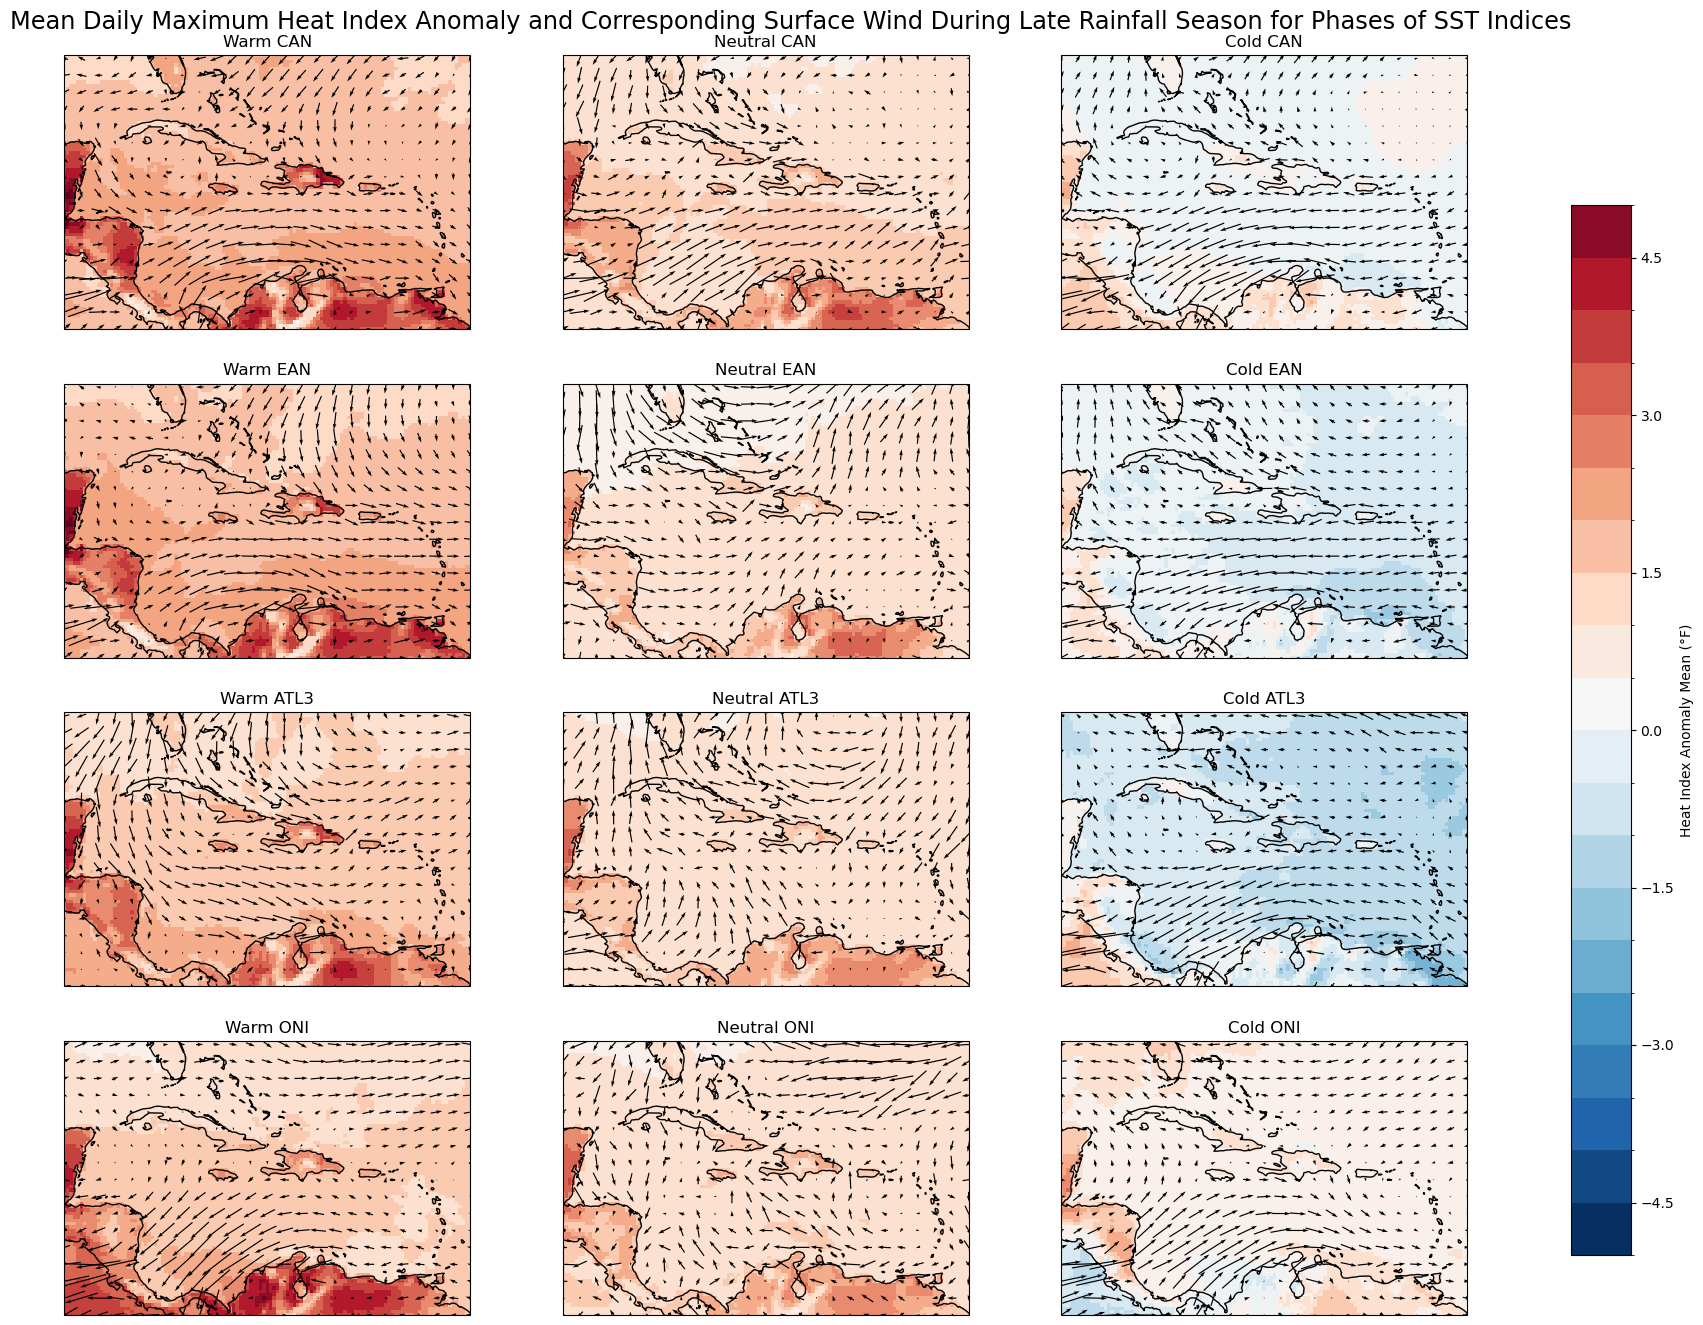

In [81]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, (da, UVds) in enumerate(zip(LRS_HI_oan, LRS_UV_oan)):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-5, 5.5, 0.5), transform=ccrs.PlateCarree())

    U_var = [var for var in UVds.data_vars if var.endswith('U')][0]
    V_var = [var for var in UVds.data_vars if var.endswith('V')][0]

    UV_coarse = UVds.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
    UV_coarse.plot.quiver(ax=ax, x='longitude', y='latitude', u=U_var, v=V_var, transform=ccrs.PlateCarree(), add_guide=False)
    
    
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='Heat Index Anomaly Mean (°F)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean Daily Maximum Heat Index Anomaly and Corresponding Surface Wind During Late Rainfall Season for Phases of SST Indices', fontsize='xx-large')
plt.show()

## Significant HI  and winds

## Significant RH and T